# Intro

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

%cd /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


In [62]:
TEST_RESULTS_PATH_SEG = 'thesis-figures/extended_cbm/results/2_test_metrics_aab_seg.parquet'
VAL_RESULTS_PATH_RAW = 'thesis-figures/extended_cbm/results/1_extended_cbm_results.parquet'

In [63]:
def create_summary_table(df: pd.DataFrame, filter_tag:list[str], reference_measure:str):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")

    # filter df for each column where df[column] is true
    for tag in filter_tag:
        col = f"tag_{tag}"
        if col not in df.columns:
            raise ValueError(f"Tag-Spalte {col} existiert nicht im DataFrame.")
        df = df[df[col] == True]

    if df.empty:
        print("DataFrame nach Tag-Filter leer.")
        return df

    # Sicherstellen, dass innerhalb jedes Runs nach step sortiert ist
    df = df.sort_values(["run_id", "_step"]).copy()

    # Epoch als laufende Evaluation pro run_id (startet bei 0)
    df["epoch"] = df.groupby("run_id").cumcount()

    # Bestes F1-Concept pro Run auswählen
    best_per_run = (
        df.loc[df.groupby("run_id")[reference_measure].idxmax()]
        .reset_index(drop=True)
    )
    
    # Speichern
    best_per_run.to_parquet("thesis-figures/extended_cbm/results/2_extended_cbm_results_best.parquet")
    print("Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet")
    return best_per_run

In [64]:
test_results = pd.read_parquet(TEST_RESULTS_PATH_SEG)
val_results_raw = pd.read_parquet(VAL_RESULTS_PATH_RAW)

val_results_raw = val_results_raw[val_results_raw["tag_aab-seg-benchmark"] == True].rename(columns={"Mean Dice": "Dice"})

In [65]:
test_results.head()

,run_id,Total Loss,Mean Dice,Mean IoU,Concept Activations $F_1$-Score,Precision Concepts,Recall Concepts,Concept Accuracy,Label $F_1$-Score,Label Accuracy,Foreground Dice,Concept Module,Segmentation Module,Dataset,Runtime,epoch,dataset
0,1jpajf8d,0.0,0.899233,0.874026,0.0,0.0,0.0,0.814066,0.022857,0.022857,0.641682,Global Average Pooling,SegDINO,None,None,23.0,FunnyBirds
0,pbvhti5j,0.0,0.450751,0.424364,0.0,0.0,0.0,0.772622,0.003452,0.003452,0.510557,Global Average Pooling,SegDINO,None,None,7.0,CUB_112
0,q0gevqso,0.0,0.502665,0.475892,0.0,0.0,0.0,0.772622,0.005178,0.005178,0.561333,Global Average Pooling,SETR-PUP,None,None,12.0,CUB_112
0,xlp9yh1g,0.0,0.931363,0.913494,0.0,0.0,0.0,0.813846,0.014286,0.014286,0.821493,Global Average Pooling,SETR-PUP,None,None,23.0,FunnyBirds
0,5bhtbcxc,0.0,0.521851,0.496925,0.0,0.0,0.0,0.772617,0.005005,0.005005,0.508559,Global Average Pooling,Upscaled SingleLayer,None,None,47.0,CUB_112


In [66]:
test_results['run_id'].nunique(), val_results_raw['run_id'].nunique()

(8, 8)

In [67]:
val_results_raw.head()

,_step,Recall Concepts,Precision Concepts,Total Loss,Mean IoU,Foreground Dice,$F_1$-Score Concepts,Dice,Concept Accuracy,Runtime,...,Segmentation Module,Concept Criterion,Use Soft Labels,unified_model,Dataset,Concept Loss,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff
69,781,0.0,0.0,0.244985,0.783426,0.526457,0.0,0.808431,0.814103,1012.193566,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None
70,1562,0.0,0.0,0.222595,0.804496,0.566505,0.0,0.830091,0.814103,2016.045149,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None
71,2343,0.0,0.0,0.214856,0.809113,0.581208,0.0,0.834639,0.814103,3008.361526,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None
72,3124,0.0,0.0,0.207240,0.836924,0.592973,0.0,0.862481,0.814103,4010.789536,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None
73,3906,0.0,0.0,0.203963,0.832565,0.599443,0.0,0.858034,0.814103,5012.435945,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None


In [68]:
val_results_raw_runtime = val_results_raw[['run_id', 'Dataset', 'Segmentation Module', '_step', 'Runtime']].copy().sort_values(['run_id', '_step'])

val_results_raw_runtime['normalized_epoch'] = val_results_raw_runtime.groupby('run_id').cumcount() + 1

# 1. Die Zeilen mit der maximalen Epoche pro Run extrahieren
last_epochs = val_results_raw_runtime.loc[val_results_raw_runtime.groupby('run_id')['normalized_epoch'].idxmax()]

# 2. Durchschnittliche Runtime pro Epoche in Minuten berechnen
# (Gesamtzeit / Anzahl Epochen) / 60
last_epochs['avg_runtime_min_per_epoch'] = (last_epochs['Runtime'] / last_epochs['normalized_epoch']) / 60

# 3. Das Ergebnis für eine Übersicht zusammenstellen
avg_runtime_df = last_epochs[['run_id', 'Dataset', 'Segmentation Module', 'avg_runtime_min_per_epoch']]

avg_runtime_df

,run_id,Dataset,Segmentation Module,avg_runtime_min_per_epoch
93,1jpajf8d,FunnyBirds,SegDINO,16.650382
183,5bhtbcxc,CUB_112,Upscaled SingleLayer,9.862067
272,av3igr7l,CUB_112,Upscaled MultiLayer,10.014321
43,c01q4i6o,FunnyBirds,Upscaled MultiLayer,46.475751
24,i6n2g0yg,FunnyBirds,Upscaled SingleLayer,22.793096
472,pbvhti5j,CUB_112,SegDINO,7.589578
372,q0gevqso,CUB_112,SETR-PUP,7.710357
68,xlp9yh1g,FunnyBirds,SETR-PUP,14.265098


In [69]:
avg_runtime_df['avg_runtime_min_per_epoch']

93     16.650382
183     9.862067
272    10.014321
43     46.475751
24     22.793096
472     7.589578
372     7.710357
68     14.265098
Name: avg_runtime_min_per_epoch, dtype: float64

In [70]:
val_results = create_summary_table(val_results_raw, filter_tag=["aab-seg-benchmark"], reference_measure="Foreground Dice").rename(columns={'Mean Dice': 'Dice'})


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: 2_extended_cbm_results_best.parquet


In [71]:
val_results.head()

,_step,Recall Concepts,Precision Concepts,Total Loss,Mean IoU,Foreground Dice,$F_1$-Score Concepts,Dice,Concept Accuracy,Runtime,...,Segmentation Module,Concept Criterion,Use Soft Labels,unified_model,Dataset,Concept Loss,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff
0,18749,0.0,0.0,0.185839,0.868756,0.634571,0.0,0.894241,0.814103,23978.100935,...,SegDINO,None,no,segdino_b,FunnyBirds,NaN,None,None,None,None
1,3596,0.0,0.0,0.333585,0.495834,0.504920,0.0,0.520585,0.774080,28085.072067,...,Upscaled SingleLayer,None,no,None,CUB_112,NaN,None,None,None,None
2,1498,0.0,0.0,0.314282,0.478783,0.584985,0.0,0.504340,0.774080,11804.950222,...,Upscaled MultiLayer,None,no,None,CUB_112,NaN,None,None,None,None
3,14062,0.0,0.0,0.047301,0.887759,0.917422,0.0,0.898199,0.814103,50196.237235,...,Upscaled MultiLayer,None,no,None,FunnyBirds,NaN,None,None,None,None
4,14843,0.0,0.0,0.238090,0.819017,0.535964,0.0,0.835222,0.814103,25989.591970,...,Upscaled SingleLayer,None,no,None,FunnyBirds,NaN,None,None,None,None


# Metrics over time

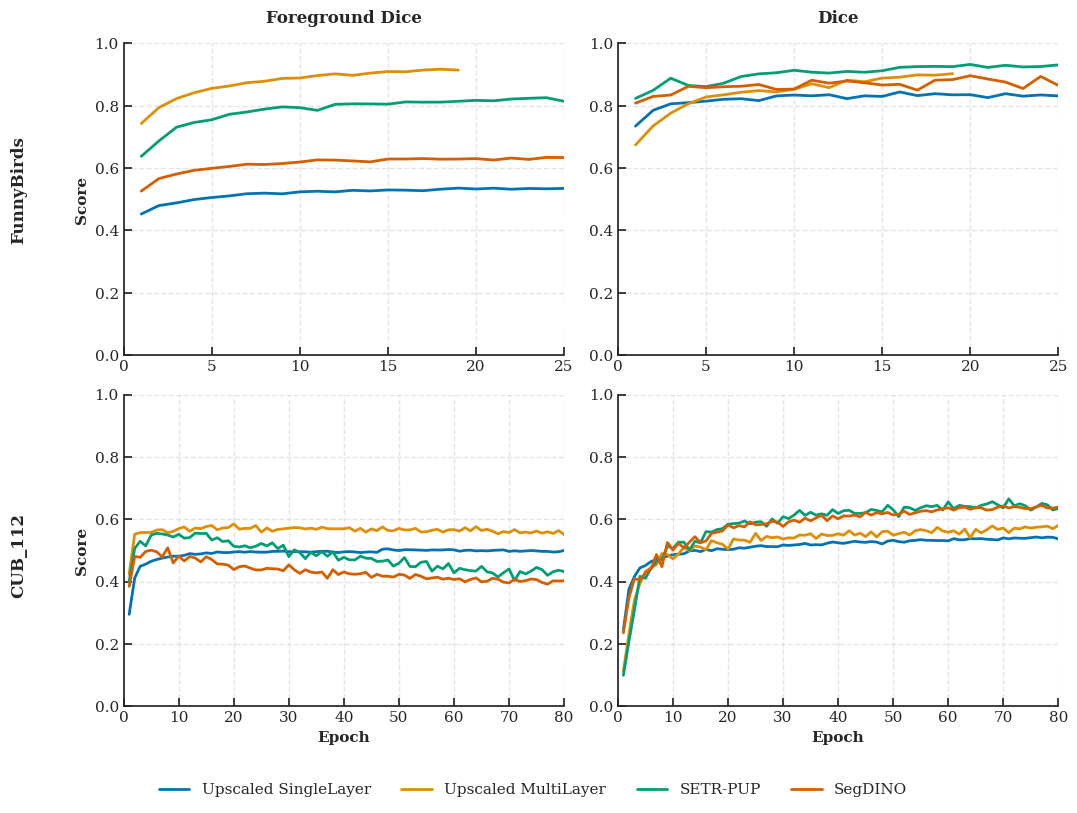

In [72]:
# --- Styling ---
sns.set_theme(style="ticks")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "xtick.direction": "in",
    "ytick.direction": "in"
})

datasets = ["FunnyBirds", "CUB_112"]
metrics = ["Foreground Dice", "Dice"]
seg_modules = ["Upscaled SingleLayer", "Upscaled MultiLayer", "SETR-PUP", "SegDINO"]

palette = sns.color_palette("colorblind", len(seg_modules))
color_dict = dict(zip(seg_modules, palette))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 8.5), sharex=False, sharey="col")

# --- Plotting Loop ---
for i, dataset in enumerate(datasets):
    max_ep = 25 if i == 0 else 80
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        subset = val_results_raw[val_results_raw["Dataset"] == dataset]

        sns.lineplot(
            data=subset, x="normalized_epoch", y=metric, 
            hue="Segmentation Module", hue_order=seg_modules,
            palette=color_dict, linewidth=2, ax=ax, legend=True
        )

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.set_xlim(0, max_ep)
        ax.set_ylim(0, 1.0)
        
        if i == 0:
            ax.set_title(metric, pad=15, fontweight='bold')
        
        ax.set_xlabel("Epoch" if i == 1 else "")
        ax.set_ylabel("Score" if j == 0 else "")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.get_legend().remove()

# --- Dataset Labels (Links) - Clean & Paper-like ---
# Wir nutzen fig.text ohne Box und nur mit den Namen
fig.text(0.04, 0.75, 'FunnyBirds', va='center', ha='right', rotation='vertical', 
         fontsize=12, fontweight='bold')
fig.text(0.04, 0.32, 'CUB_112', va='center', ha='right', rotation='vertical', 
         fontsize=12, fontweight='bold')

# --- Gemeinsame Legende UNTEN ---
legend_elements = [Line2D([0], [0], color=color_dict[m], lw=2, label=m) for m in seg_modules]

fig.legend(
    handles=legend_elements, 
    loc="lower center", 
    ncol=4, 
    frameon=False, 
    bbox_to_anchor=(0.5, 0.02)
)

# Das rect wurde leicht angepasst (0.07 statt 0.08), 
# damit der Text links nicht zu weit weg steht
plt.tight_layout(rect=[0.07, 0.08, 1, 0.98]) 
plt.savefig("thesis-figures/extended_cbm/outputs/segmentation_benchmark.pdf", dpi=300)
plt.show()

# Table

In [73]:
val_results.columns

Index(['_step', 'Recall Concepts', 'Precision Concepts', 'Total Loss',
       'Mean IoU', 'Foreground Dice', '$F_1$-Score Concepts', 'Dice',
       'Concept Accuracy', 'Runtime', 'normalized_epoch', 'epoch', 'tag_Final',
       'tag_aab-seg-benchmark', 'run_id', 'Concept Module',
       'Segmentation Module', 'Concept Criterion', 'Use Soft Labels',
       'unified_model', 'Dataset', 'Concept Loss', 'tag_aab-con',
       'tag_aab-con-maskreg-intro', 'tag_aab-soft-bce', 'tag_aab-aff'],
      dtype='object')

In [74]:
val_results_paper = val_results[['run_id', 'Dataset', 'Segmentation Module', 'Mean IoU', 'Foreground Dice', 'Dice', 'Runtime']].copy()

In [75]:
metrics = ['Mean IoU', 'Foreground Dice', 'Dice']

df_wide = (
    val_results_paper
        .sort_values(by=["Dataset", "Segmentation Module"])
        .pivot(
            index='Segmentation Module',
            columns='Dataset',
            values=metrics
        )
)

# MultiIndex-Spalten tauschen → Dataset oben, Metrik darunter
df_wide = df_wide.swaplevel(0, 1, axis=1)

# Optional: sauber sortieren
df_wide = df_wide.sort_index(axis=1, level=0)

df_wide

Dataset                CUB_112                           FunnyBirds  \
                          Dice Foreground Dice  Mean IoU       Dice   
Segmentation Module                                                   
SegDINO               0.447383        0.508251  0.421198   0.894241   
SETR-PUP              0.501616        0.555497  0.475141   0.926009   
Upscaled SingleLayer  0.520585        0.504920  0.495834   0.835222   
Upscaled MultiLayer   0.504340        0.584985  0.478783   0.898199   

Dataset                                         
                     Foreground Dice  Mean IoU  
Segmentation Module                             
SegDINO                     0.634571  0.868756  
SETR-PUP                    0.826034  0.908411  
Upscaled SingleLayer        0.535964  0.819017  
Upscaled MultiLayer         0.917422  0.887759

In [76]:
print(df_wide.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
Dataset & \multicolumn{3}{r}{CUB_112} & \multicolumn{3}{r}{FunnyBirds} \\
 & Dice & Foreground Dice & Mean IoU & Dice & Foreground Dice & Mean IoU \\
Segmentation Module &  &  &  &  &  &  \\
\midrule
SegDINO & 0.447383 & 0.508251 & 0.421198 & 0.894241 & 0.634571 & 0.868756 \\
SETR-PUP & 0.501616 & 0.555497 & 0.475141 & 0.926009 & 0.826034 & 0.908411 \\
Upscaled SingleLayer & 0.520585 & 0.504920 & 0.495834 & 0.835222 & 0.535964 & 0.819017 \\
Upscaled MultiLayer & 0.504340 & 0.584985 & 0.478783 & 0.898199 & 0.917422 & 0.887759 \\
\bottomrule
\end{tabular}



# Image Examples

In [77]:
import torch
from tqdm import tqdm

from architecture.extended_cbm import ExtendedCBMOutput, init_from_checkpoint
from cbm_datasets import Batch, get_dataloader, get_datasets


In [78]:
train_dataset_fb, val_dataset_fb, test_dataset_fb, _, _, _ = get_datasets(dataset_name='FunnyBirds', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale='small',
                                                        attr_level='image')

train_dataset_cub, val_dataset_cub, test_dataset_cub, _, _, _ = get_datasets(dataset_name='CUB_112', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale='small',
                                                        attr_level='image')

train_loader_fb, val_loader_fb, test_loader_fb = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_fb, val_dataset=val_dataset_fb, 
                                                       test_dataset=test_dataset_fb)

train_loader_cub, val_loader_cub, test_loader_cub = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_cub, val_dataset=val_dataset_cub, 
                                                       test_dataset=test_dataset_cub)

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
iter_obj_fb = iter(test_loader_fb)
batch_fb: Batch = next(iter_obj_fb).to(device)

iter_obj_cub = iter(test_loader_cub)
batch_cub: Batch = next(iter_obj_cub).to(device)

In [80]:
def load_and_predict(run_ids:list[str], epochs:list[int], datasets:list[str], batch:Batch,):

    predictions: list[ExtendedCBMOutput] = [] 
    for run_id, epoch, dataset in tqdm(zip(run_ids, epochs, datasets)):
    
        model = init_from_checkpoint(run_id=run_id, epoch=epoch, dataset=dataset.lower(), device=device)

        pred: ExtendedCBMOutput = model(batch.images)
        predictions.append(pred)

    return predictions

In [81]:
def plot_concept_masks_paper(predictions, gt_vector, concept_names, concept_splitter, images, batch_idx=0, alpha=0.3, cmap='magma'):
    """
    Erstellt einen strukturierten Plot für das Paper:
    - Gruppiert nach Körperteilen.
    - Zeigt Masken-Predictions.
    - Markiert Ground Truth (GT) Aktivierung durch Titel-Farbe (Grün = Aktiv, Rot = Inaktiv).
    """
    # Gruppierung der Konzepte (wir suchen nach dem Präfix vor dem Bindestrich)
    categories = {}
    for i, name in enumerate(concept_names):
        cat = name.split(concept_splitter)[0]
        if cat not in categories:
            categories[cat] = []
        categories[cat].append((i, name))

    num_categories = len(categories)

    image = images[batch_idx].permute(1,2,0).cpu().numpy()
    
    # Bestimme die maximale Anzahl an Konzepten pro Kategorie für die Spaltenanzahl
    max_cols = max(len(v) for v in categories.values())

    fig, axes = plt.subplots(num_categories, max_cols, 
                             figsize=(max_cols * 2.5, num_categories * 3))
    
    all_logits = predictions.segmentation_module.mask_logits[batch_idx].detach().cpu()

    for row_idx, (cat_name, items) in enumerate(categories.items()):
        for col_idx in range(max_cols):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(items):
                concept_idx, name = items[col_idx]
                
                # Maske berechnen
                mask = all_logits[concept_idx].sigmoid().numpy()
                is_active_gt = gt_vector[batch_idx, concept_idx] == 1
                
                # Plotting
                ax.imshow(image)  # zuerst das RGB-Bild (ohne cmap!)
                ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
                
                # Titel Styling: Grün wenn GT aktiv, sonst Grau/Rot
                color = 'green' if is_active_gt else 'black'
                weight = 'bold' if is_active_gt else 'normal'
                label = f"{name}\n(GT: {'Active' if is_active_gt else 'Off'})"
                
                ax.set_title(label, fontsize=10, color=color, fontweight=weight)
                
                # Optional: Rahmenfarbe passend zur GT
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(2 if is_active_gt else 0.5)
            else:
                # Leere Subplots ausblenden
                ax.axis('off')
            
            ax.set_xticks([])
            ax.set_yticks([])

        # Zeilenbeschriftung links
        axes[row_idx, 0].set_ylabel(cat_name.upper(), fontsize=14, fontweight='bold')

    plt.tight_layout()
    # Speichern als PDF für beste Qualität im Paper
    plt.savefig("concept_ablation_visual_fb_all-concepts.pdf", bbox_inches='tight', dpi=300)
    plt.show()

In [82]:
def plot_single_concept_multi_model_paper(
    predictions_list,          # Liste von Model-Predictions
    model_names,               # Liste der Modellnamen (gleiche Reihenfolge)
    concept_id,                # Zu visualisierendes Konzept
    concept_names,
    gt_vector,
    images,
    batch_idx=0,
    alpha=0.35,
    cmap="magma",
    save_path=None
):
    """
    Paper-ready Plot:
    - Eine Reihe
    - Links: Originalbild
    - Danach: Predictions mehrerer Modelle
    - GT-Aktivierung wird farblich markiert
    """

    #denomalize images
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images = images * std + mean

    assert len(predictions_list) == len(model_names)

    image = images[batch_idx].permute(1, 2, 0).cpu().numpy()
    concept_name = concept_names[concept_id]
    is_active_gt = gt_vector[batch_idx, concept_id] == 1

    num_models = len(predictions_list)
    total_cols = num_models + 1  # +1 für Originalbild

    fig, axes = plt.subplots(
        1,
        total_cols,
        figsize=(total_cols * 3.2, 3.5)
    )

    # -----------------------
    # Originalbild
    # -----------------------
    axes[0].imshow(image)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    # -----------------------
    # Modelle
    # -----------------------
    for i, (predictions, model_name) in enumerate(zip(predictions_list, model_names)):
        ax = axes[i + 1]

        logits = predictions.segmentation_module.mask_logits[batch_idx]
        mask = logits[concept_id].sigmoid().detach().cpu().numpy()

        ax.imshow(image)
        ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)

        # Titel-Formatierung
        color = "green" if is_active_gt else "black"
        weight = "bold" if is_active_gt else "normal"

        ax.set_title(
            model_name,
            fontsize=10,
            color=color,
            fontweight=weight
        )

        # Rahmenfarbe
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2 if is_active_gt else 0.8)

        ax.set_xticks([])
        ax.set_yticks([])

    # -----------------------
    # Gesamttitel
    # -----------------------
    fig.suptitle(
        f"Concept: {concept_name} | GT: {'Active' if is_active_gt else 'Inactive'}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

In [83]:
test_results.head()

,run_id,Total Loss,Mean Dice,Mean IoU,Concept Activations $F_1$-Score,Precision Concepts,Recall Concepts,Concept Accuracy,Label $F_1$-Score,Label Accuracy,Foreground Dice,Concept Module,Segmentation Module,Dataset,Runtime,epoch,dataset
0,1jpajf8d,0.0,0.899233,0.874026,0.0,0.0,0.0,0.814066,0.022857,0.022857,0.641682,Global Average Pooling,SegDINO,None,None,23.0,FunnyBirds
0,pbvhti5j,0.0,0.450751,0.424364,0.0,0.0,0.0,0.772622,0.003452,0.003452,0.510557,Global Average Pooling,SegDINO,None,None,7.0,CUB_112
0,q0gevqso,0.0,0.502665,0.475892,0.0,0.0,0.0,0.772622,0.005178,0.005178,0.561333,Global Average Pooling,SETR-PUP,None,None,12.0,CUB_112
0,xlp9yh1g,0.0,0.931363,0.913494,0.0,0.0,0.0,0.813846,0.014286,0.014286,0.821493,Global Average Pooling,SETR-PUP,None,None,23.0,FunnyBirds
0,5bhtbcxc,0.0,0.521851,0.496925,0.0,0.0,0.0,0.772617,0.005005,0.005005,0.508559,Global Average Pooling,Upscaled SingleLayer,None,None,47.0,CUB_112


In [84]:
test_results

,run_id,Total Loss,Mean Dice,Mean IoU,Concept Activations $F_1$-Score,Precision Concepts,Recall Concepts,Concept Accuracy,Label $F_1$-Score,Label Accuracy,Foreground Dice,Concept Module,Segmentation Module,Dataset,Runtime,epoch,dataset
0,1jpajf8d,0.0,0.899233,0.874026,0.0,0.0,0.0,0.814066,0.022857,0.022857,0.641682,Global Average Pooling,SegDINO,None,None,23.0,FunnyBirds
0,pbvhti5j,0.0,0.450751,0.424364,0.0,0.0,0.0,0.772622,0.003452,0.003452,0.510557,Global Average Pooling,SegDINO,None,None,7.0,CUB_112
0,q0gevqso,0.0,0.502665,0.475892,0.0,0.0,0.0,0.772622,0.005178,0.005178,0.561333,Global Average Pooling,SETR-PUP,None,None,12.0,CUB_112
0,xlp9yh1g,0.0,0.931363,0.913494,0.0,0.0,0.0,0.813846,0.014286,0.014286,0.821493,Global Average Pooling,SETR-PUP,None,None,23.0,FunnyBirds
0,5bhtbcxc,0.0,0.521851,0.496925,0.0,0.0,0.0,0.772617,0.005005,0.005005,0.508559,Global Average Pooling,Upscaled SingleLayer,None,None,47.0,CUB_112
0,i6n2g0yg,0.0,0.837404,0.820989,0.0,0.0,0.0,0.814176,0.017143,0.017143,0.543046,Global Average Pooling,Upscaled SingleLayer,None,None,18.0,FunnyBirds
0,av3igr7l,0.0,0.509628,0.484018,0.0,0.0,0.0,0.772622,0.003797,0.003797,0.589982,Global Average Pooling,Upscaled MultiLayer,None,None,19.0,CUB_112
0,c01q4i6o,0.0,0.906514,0.896194,0.0,0.0,0.0,0.814396,0.025714,0.025714,0.915336,Global Average Pooling,Upscaled MultiLayer,None,None,17.0,FunnyBirds


In [85]:
test_results_cub = test_results[test_results["dataset"] == "CUB_112"]
test_results_fb = test_results[test_results["dataset"] == "FunnyBirds"]

predictions_cub = load_and_predict(run_ids=test_results_cub['run_id'].to_list(), epochs=test_results_cub['epoch'].astype(int).to_list(), datasets=test_results_cub['dataset'].to_list(), batch=batch_cub)
predictions_fb = load_and_predict(run_ids=test_results_fb['run_id'].to_list(), epochs=test_results_fb['epoch'].astype(int).to_list(), datasets=test_results_fb['dataset'].to_list(), batch=batch_fb)

2it [00:03,  1.70s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
3it [00:05,  1.84s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
4it [00:06,  1.75s/it]
2it [00:02,  1.15s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
3it [00:03,  1.25s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
4it [00:04,  1.25s/it]


In [86]:
test_results

,run_id,Total Loss,Mean Dice,Mean IoU,Concept Activations $F_1$-Score,Precision Concepts,Recall Concepts,Concept Accuracy,Label $F_1$-Score,Label Accuracy,Foreground Dice,Concept Module,Segmentation Module,Dataset,Runtime,epoch,dataset
0,1jpajf8d,0.0,0.899233,0.874026,0.0,0.0,0.0,0.814066,0.022857,0.022857,0.641682,Global Average Pooling,SegDINO,None,None,23.0,FunnyBirds
0,pbvhti5j,0.0,0.450751,0.424364,0.0,0.0,0.0,0.772622,0.003452,0.003452,0.510557,Global Average Pooling,SegDINO,None,None,7.0,CUB_112
0,q0gevqso,0.0,0.502665,0.475892,0.0,0.0,0.0,0.772622,0.005178,0.005178,0.561333,Global Average Pooling,SETR-PUP,None,None,12.0,CUB_112
0,xlp9yh1g,0.0,0.931363,0.913494,0.0,0.0,0.0,0.813846,0.014286,0.014286,0.821493,Global Average Pooling,SETR-PUP,None,None,23.0,FunnyBirds
0,5bhtbcxc,0.0,0.521851,0.496925,0.0,0.0,0.0,0.772617,0.005005,0.005005,0.508559,Global Average Pooling,Upscaled SingleLayer,None,None,47.0,CUB_112
0,i6n2g0yg,0.0,0.837404,0.820989,0.0,0.0,0.0,0.814176,0.017143,0.017143,0.543046,Global Average Pooling,Upscaled SingleLayer,None,None,18.0,FunnyBirds
0,av3igr7l,0.0,0.509628,0.484018,0.0,0.0,0.0,0.772622,0.003797,0.003797,0.589982,Global Average Pooling,Upscaled MultiLayer,None,None,19.0,CUB_112
0,c01q4i6o,0.0,0.906514,0.896194,0.0,0.0,0.0,0.814396,0.025714,0.025714,0.915336,Global Average Pooling,Upscaled MultiLayer,None,None,17.0,FunnyBirds


In [87]:
test_results_cub['Segmentation Module']

0                 SegDINO
0                SETR-PUP
0    Upscaled SingleLayer
0     Upscaled MultiLayer
Name: Segmentation Module, dtype: category
Categories (4, object): ['SegDINO' < 'SETR-PUP' < 'Upscaled SingleLayer' < 'Upscaled MultiLayer']

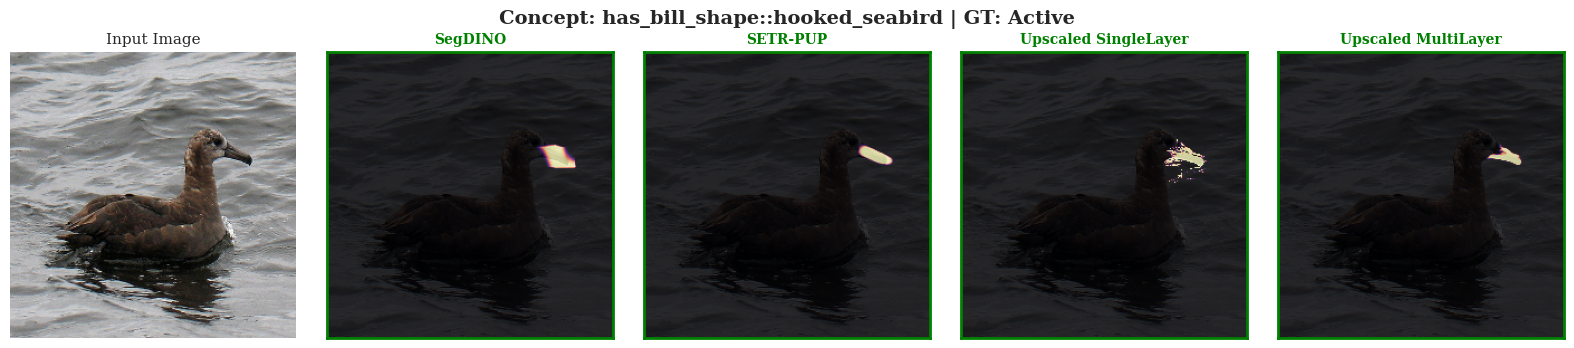

In [88]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_cub,
    model_names=test_results_cub['Segmentation Module'].tolist(),
    concept_id=1,  # Beispiel: Erstes Konzept
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_cub_1.pdf",
    batch_idx=1,
    alpha=0.8
)

In [89]:
batch_cub.concepts[3]

tensor([0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0.], device='cuda:0')

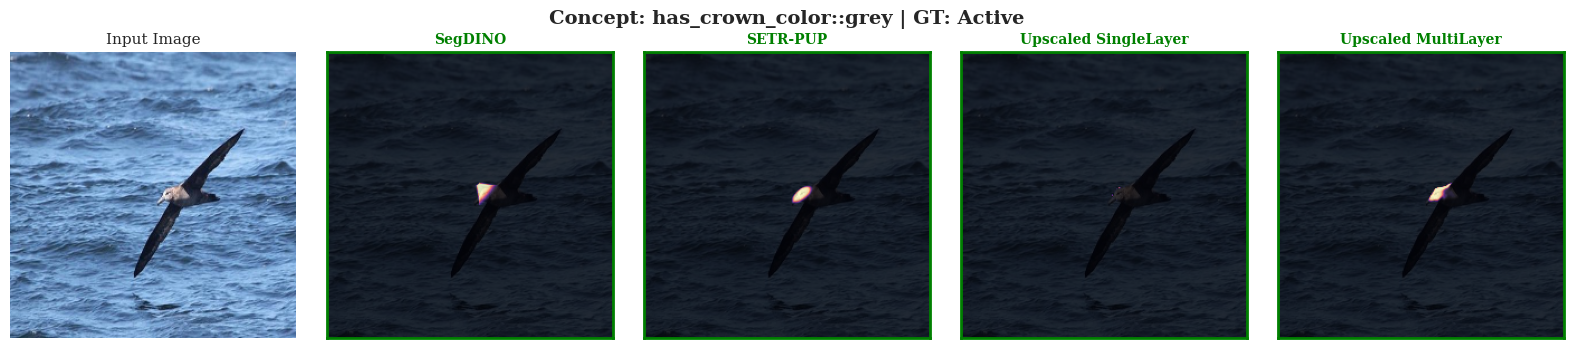

In [93]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_cub,
    model_names=test_results_cub['Segmentation Module'].tolist(),
    concept_id=104,  # Beispiel: Erstes Konzept
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_cub_2.pdf",
    batch_idx=3,
    alpha=0.8
)

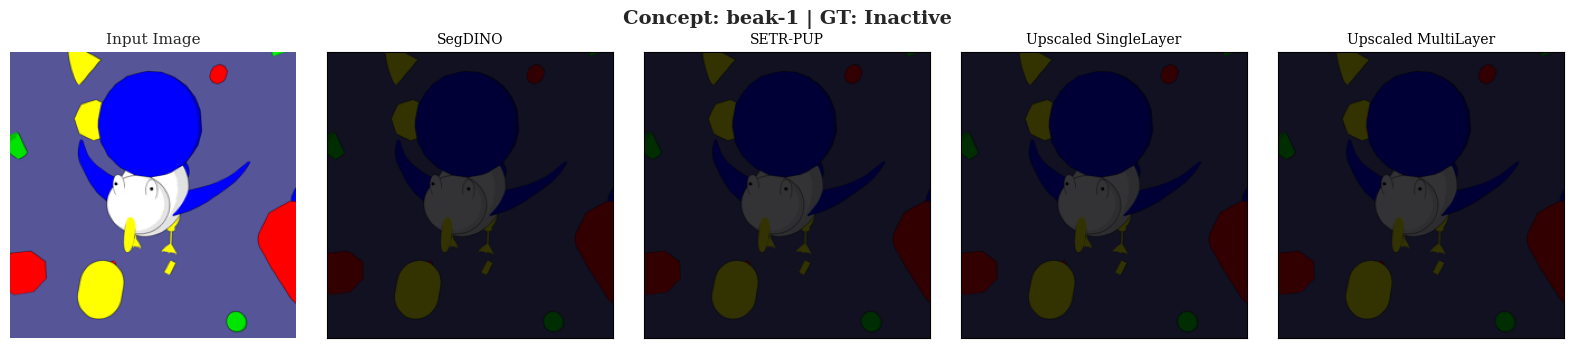

In [91]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_fb,
    model_names=test_results_fb['Segmentation Module'].tolist(),
    concept_id=1,  # Beispiel: Erstes Konzept
    concept_names=train_dataset_fb.concepts,
    gt_vector=batch_fb.concepts,
    images=batch_fb.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_fb_1.pdf",
    alpha=0.8
)

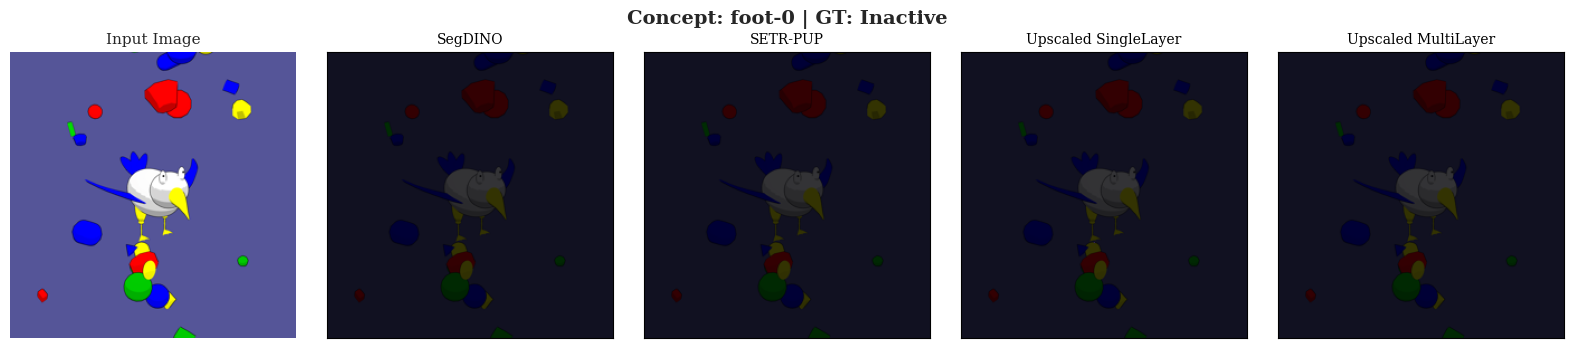

In [95]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_fb,
    model_names=test_results_fb['Segmentation Module'].tolist(),
    concept_id=7,
    batch_idx=1,
    concept_names=train_dataset_fb.concepts,
    gt_vector=batch_fb.concepts,
    images=batch_fb.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_fb_2.pdf",
    alpha=0.8
)